# 33회 ADP 복원 

# 기계학습 (60점)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings

warnings.filterwarnings('ignore')

## 데이터 설명
- 데이터 출처 : https://archive.ics.uci.edu/ml/datasets/HCV+data 후처리
- 데이터 링크 : ./data/p1.csv
- 데이터 설명 : 혈액수치 데이터, 간염 정도에 따른

Category (종속변수) 
- 0: 정상
- 1,2,3 (간염 정도, 심각성 : 3>2>1, 3은 간경화)


In [272]:
dt1 = pd.read_csv("https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p1.csv")
print(dt1.info())
display(dt1.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  608 non-null    object 
 1   Age       608 non-null    int64  
 2   Sex       608 non-null    object 
 3   ALB       607 non-null    float64
 4   ALP       590 non-null    float64
 5   ALT       607 non-null    float64
 6   AST       608 non-null    float64
 7   BIL       608 non-null    float64
 8   CHE       608 non-null    float64
 9   CHOL      598 non-null    float64
 10  CREA      608 non-null    float64
 11  GGT       608 non-null    float64
 12  PROT      607 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 61.9+ KB
None


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=B,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=B,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=B,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3


In [273]:
dt1.isna().sum()

Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

5개의 변수에서 결측치가 발견되었다.(ALB, ALP:18, ALT, CHOL:10, PROT)

In [296]:
# 기초통계량 확인
display(dt1.describe(include='object').T)
display(dt1.describe().T)

,count,unique,top,freq
Category,608,4,0=B,533
Sex,608,2,m,371


,count,mean,std,min,25%,50%,75%,max
Age,608.0,47.291118,9.992705,19.00,39.00,47.00,54.000,77.00
ALB,607.0,41.818781,5.406717,20.00,39.00,42.00,45.250,82.20
ALP,590.0,67.821017,25.274423,11.30,52.50,66.00,79.525,416.60
ALT,607.0,27.601318,21.227539,0.90,16.40,23.00,32.750,258.00
AST,608.0,34.369408,32.622442,12.00,21.60,25.85,32.800,324.00
BIL,608.0,11.474013,19.770558,1.80,5.30,7.30,11.300,254.00
CHE,608.0,8.204885,2.168400,1.42,6.95,8.27,9.585,16.41
CHOL,598.0,5.378829,1.119394,1.43,4.62,5.30,6.075,9.67
CREA,608.0,81.513158,49.720652,8.00,68.00,77.00,88.000,1079.10
GGT,608.0,38.243914,51.953220,4.50,15.70,23.25,39.200,650.90


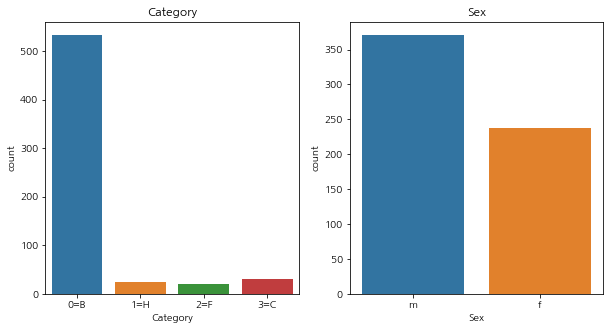

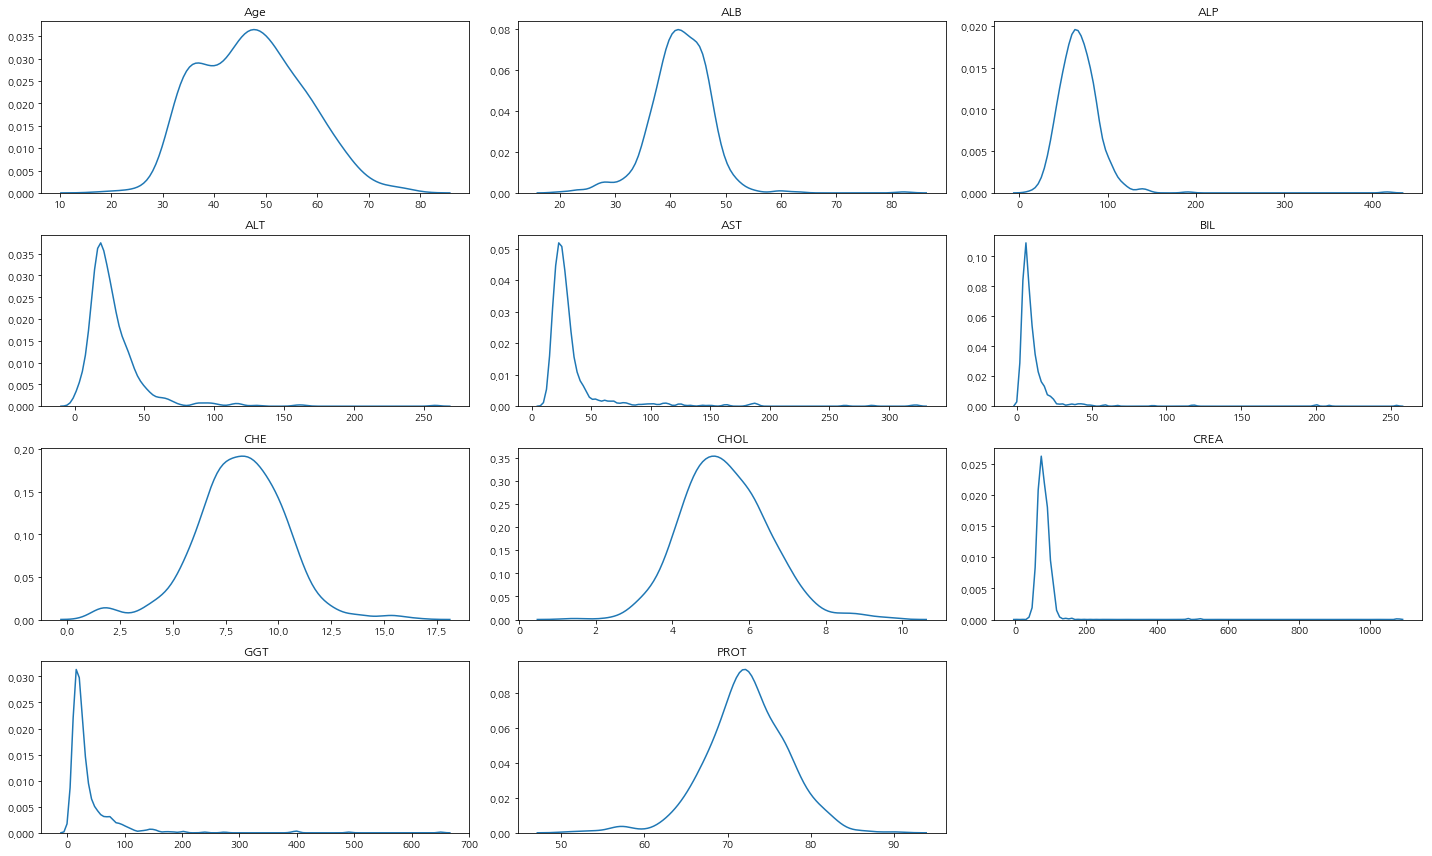

In [298]:
#분포 확인
c_cols = dt1.select_dtypes('O').columns
n_cols = dt1.select_dtypes('number').columns

#count_plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i, col in enumerate(c_cols):
    sns.countplot(dt1[col], ax=ax[i])
    ax[i].set_title(col)
plt.show()
#kde plot
fig, ax = plt.subplots(4, 3, figsize=(20, 12))

for i, col in enumerate(n_cols):
    x = i // 3
    y = i % 3
    sns.kdeplot(data=dt1[col], ax=ax[x, y], legend=False)
    ax[x, y].set_title(col)
ax[3, 2].remove()
plt.tight_layout()
plt.show()

통계량과 분포 그래프(카테고리형: cout plot, 연속형: kde plot)를 통해 다음과 같은 사실을 알 수 있다.  
- 간염이 아닌 사람의 비율이 나머지 레이블보다 압도적으로 높다.(불균형 데이터)
- 남성의 비율이 여성보다 높다. 
- CHE, PROT를 제외한 모든 설명변수가 오른쪽 꼬리가 긴 양의 왜도를 가짐

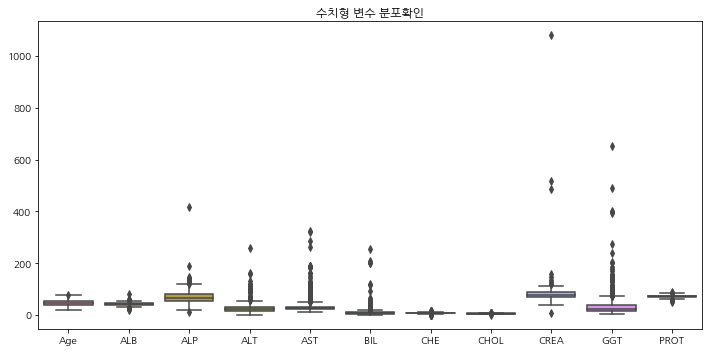

In [301]:
# 이상치 확인을 위한 boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=dt1[n_cols])
plt.title('수치형 변수 분포확인')
plt.tight_layout()
plt.show()

많은 변수에서 outlier로 보이는 point들이 식별된다.  
특히 CREA, GGT 변수의 경우 상당히 높은 값들이 식별되는데, 해당 데이터에 대한 도메인 지식이 없으며,  
이상치처럼 보이는 값들이 실제 모델 학습에서 중요할 수도 있기 때문에 제거하지 않고 학습에 사용한다.

## 1-1  결측치 처리 방안 2개 제시하고, 처리 전후 비교 및 더 나은 방안 선택하여 전처리 완료

| 처리 방법      | 설명                            | 장점                          | 단점                                | 적합한 상황                       |
| ---------- | ----------------------------- | --------------------------- | --------------------------------- | ---------------------------- |
| **대푯값 대치** | 평균, 중앙값, 최빈값 등으로 결측값을 대체      | - 빠르고 간단<br>- 대부분 모델에서 작동   | - 분포 왜곡<br>- 분산 감소<br>- 예측력 저하 가능 | - 결측 비율이 낮고<br>- 데이터가 단순할 때  |
| **결측값 제거** | 결측치 포함된 행/열을 삭제               | - 왜곡 없음<br>- 처리 간단          | - 데이터 손실 위험<br>- 표본 편향 가능성        | - 결측치가 적고 무작위 발생(MCAR)인 경우   |
| **모델링 대치** | KNN, 회귀, 다중대치 등으로 결측값을 예측해 대체 | - 변수 간 관계 반영<br>- 정확도 보존 가능 | - 구현 복잡<br>- 과적합 가능<br>- 계산 비용 큼  | - 결측이 많고<br>- 변수 간 관계가 뚜렷할 때 |


여기서는 대푯값인 중앙값 대치(Category, Sex 그룹), 그리고 결측값 제거 두 방안으로 결측치 처리 후 비교한다.

In [335]:
# 중앙값 대치
null_cols = dt1.columns[dt1.isna().sum() > 0].values
dt1_1 = dt1.copy()
for col in null_cols:
    g_median = dt1_1.groupby(['Category', 'Sex'])[col].transform('median') #각 행에 맞게 중앙값 반환
    dt1_1[col] = dt1_1[col].fillna(g_median)
dt1_1.isna().sum()

Category    0
Age         0
Sex         0
ALB         0
ALP         0
ALT         0
AST         0
BIL         0
CHE         0
CHOL        0
CREA        0
GGT         0
PROT        0
dtype: int64

In [337]:
# 결측값 제거
dt1.isna().mean()

Category    0.000000
Age         0.000000
Sex         0.000000
ALB         0.001645
ALP         0.029605
ALT         0.001645
AST         0.000000
BIL         0.000000
CHE         0.000000
CHOL        0.016447
CREA        0.000000
GGT         0.000000
PROT        0.001645
dtype: float64

결측값이 1~ 3% 미만이다. 전체 데이터 비율에서 큰 비중을 차지하지 않으므로 삭제한다. 

In [338]:
dt1_2 = dt1.copy()

dt1_2 = dt1_2.dropna()

In [342]:
# describe 확인
print("원본:결측치 포함")
display(dt1.describe()[null_cols].T)
print("종속변수, 성별 그룹 중앙값 대치")
display(dt1_1.describe()[null_cols].T)
print("결측치 삭제")
display(dt1_2.describe()[null_cols].T)

원본:결측치 포함


,count,mean,std,min,25%,50%,75%,max
ALB,607.0,41.818781,5.406717,20.00,39.00,42.0,45.250,82.20
ALP,590.0,67.821017,25.274423,11.30,52.50,66.0,79.525,416.60
ALT,607.0,27.601318,21.227539,0.90,16.40,23.0,32.750,258.00
CHOL,598.0,5.378829,1.119394,1.43,4.62,5.3,6.075,9.67
PROT,607.0,72.253213,4.932252,51.00,69.45,72.2,75.400,90.00


종속변수, 성별 그룹 중앙값 대치


,count,mean,std,min,25%,50%,75%,max
ALB,608.0,41.800987,5.420049,20.00,39.000,42.000,45.225,82.20
ALP,608.0,67.358635,25.256428,11.30,52.175,65.650,79.300,416.60
ALT,608.0,27.591118,21.211537,0.90,16.400,22.950,32.675,258.00
CHOL,608.0,5.372763,1.114565,1.43,4.620,5.305,6.060,9.67
PROT,608.0,72.248026,4.929847,51.00,69.400,72.200,75.400,90.00


결측치 삭제


,count,mean,std,min,25%,50%,75%,max
ALB,582.0,41.831443,5.369272,23.00,39.000,41.95,45.1750,82.20
ALP,582.0,67.651890,25.148941,11.30,52.500,66.00,79.3000,416.60
ALT,582.0,25.666838,14.920906,0.90,16.325,22.50,31.7500,118.10
CHOL,582.0,5.402646,1.114920,1.43,4.630,5.31,6.0875,9.67
PROT,582.0,72.106357,4.857867,51.00,69.300,72.10,75.2000,86.50


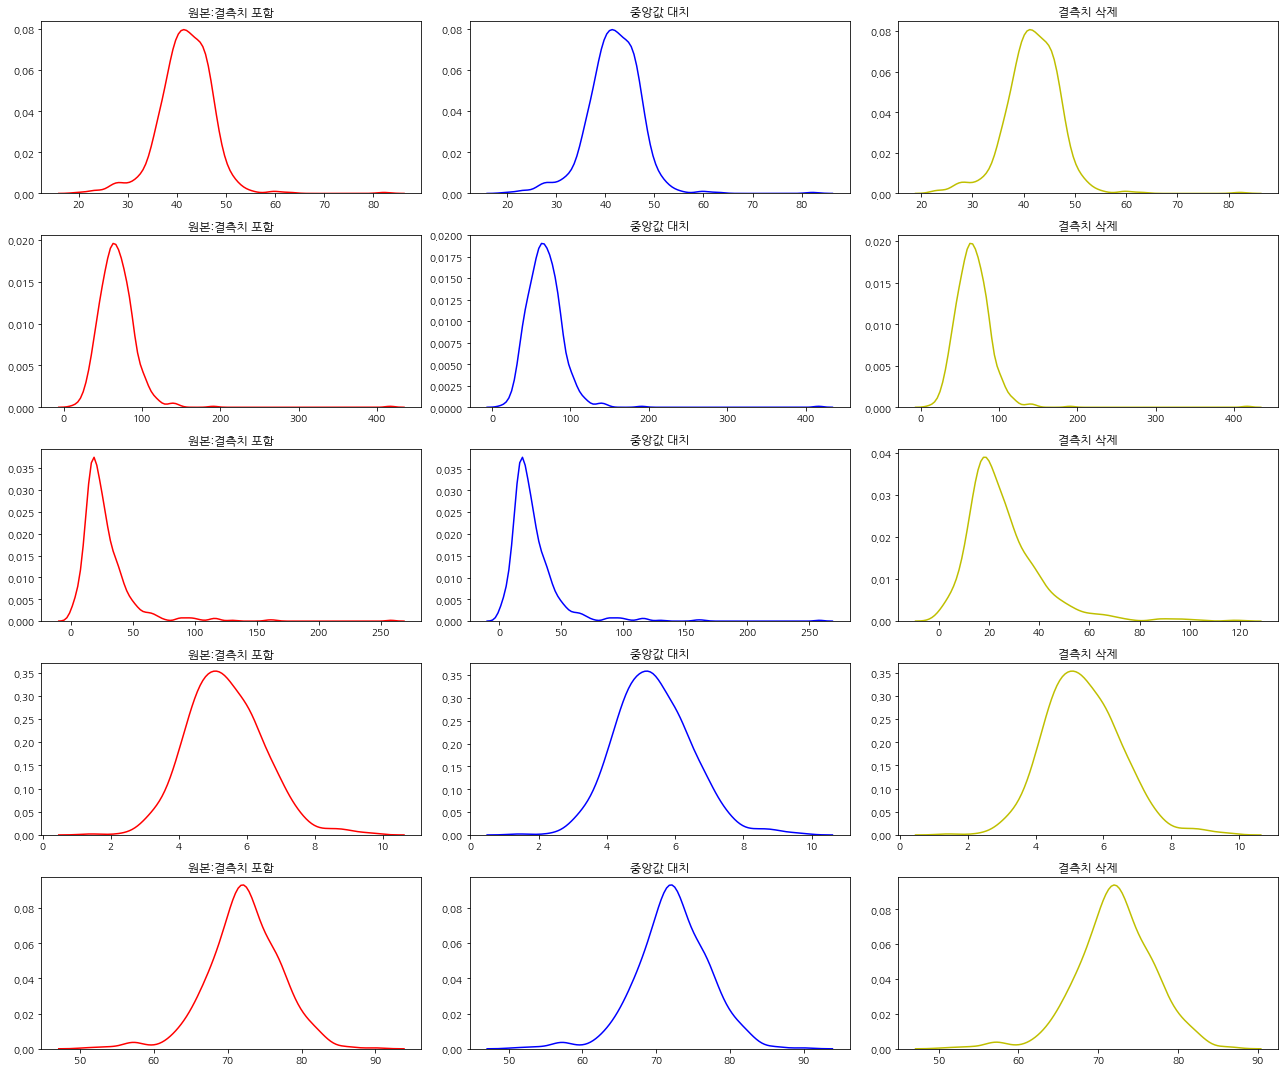

In [344]:
fig, ax = plt.subplots(5, 3, figsize=(18, 15))

for i, col in enumerate(null_cols):
    sns.kdeplot(data=dt1[col], legend=False, ax=ax[i, 0], color='r')
    sns.kdeplot(data=dt1_1[col], legend=False, ax=ax[i, 1], color='b')
    sns.kdeplot(data=dt1_2[col], legend=False, ax=ax[i, 2], color='y')
    ax[i, 0].set_title('원본:결측치 포함')
    ax[i, 1].set_title('중앙값 대치')
    ax[i, 2].set_title('결측치 삭제')
plt.tight_layout()
plt.show()

데이터의 분포를 비교하였을 때, 대동소이하다.   
데이터 활용도를 고려했을 시 중앙값 대치를 선택한다. 

## 1-2 이상치를 확인하고 처리 여부 판단 후 작업

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
df.drop(columns =['Category','Sex']).plot(kind='box',figsize=(10,5))
plt.show()
print('''
컬럼 별 이상치가 존재하는 것으로 보인다. 하지만 이상치가 간염 정도를 구분짓는 중요 요인으로 작용할 수 있기에 따로 데이터 변환을 진행하진 않는다.
''')

KeyError: "['Category' 'Sex'] not found in axis"

## 1-3 위 두 작업 적용 후 EDA 진행 및 종속변수를 기준으로 각 독립변수의 차이가 있는지 확인하라 (시각화포함)

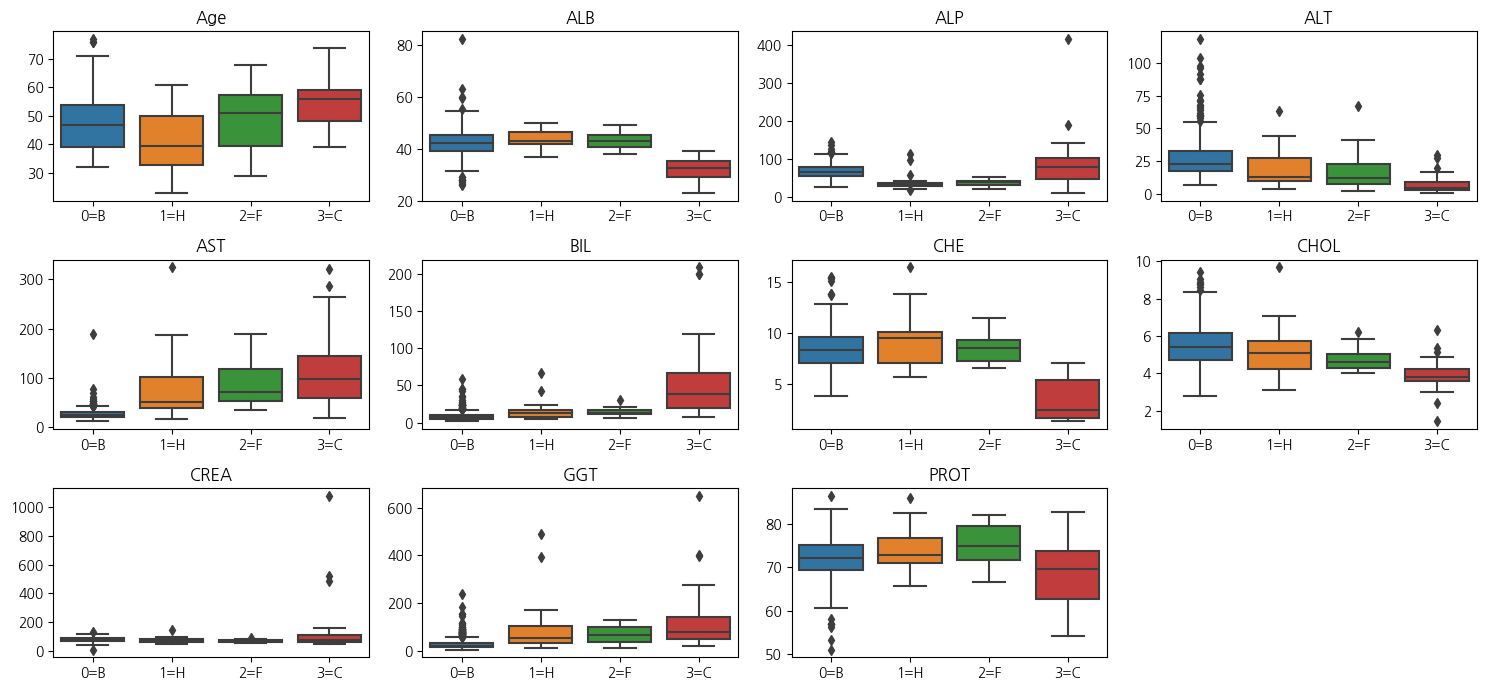

In [26]:
fig,axes = plt.subplots(3,4,figsize=(15,7))

target_col = ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE','CHOL', 'CREA', 'GGT', 'PROT']
for i,ax in enumerate(axes.flat[:-1]):
    target_df = df[['Category',target_col[i]]]
    sns.boxplot(x= 'Category',y = target_col[i] ,data = target_df, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(target_col[i])
    
axes.flat[-1].remove()
plt.tight_layout()
plt.show()

In [18]:
print('''간염 정도가 심각해질 수록, ALB,CHE,CHOL 평균 수치가 낮아짐을 확인 할 수 있으며, 
간염정도가 심각해질수록 AST,BIL,GGT 수치가 증가하고 있다. ''')

# ALB : 간에서 생성되는 단백질 
# ALP : 담즙 정체시 증가 
# ALT : 간세포가 손상되면 혈중으로 유출
# CHE : 간에서 생성되는 효소 
# CREA : 간 기능과 연관됨
# PROT : 혈장 내 단백질 총량

간염 정도가 심각해질 수록, ALB,CHE,CHOL 평균 수치가 낮아짐을 확인 할 수 있으며, 
간염정도가 심각해질수록 AST,BIL,GGT 수치가 증가하고 있다. 


# Y :범주형 별로 X: 연속형 변수

등분산 및 정규성을 확인하고 anova분석을 진행해도 좋을 듯.    
통계검정을 실시하라는 명시를 정확하게 주는 경우도 있고 차이를 확인하라고만도 표현하는 경우 있음   
이상치나 큰 차이가 시각화로 보이는 경우만 간단히 명시해줘도 괜찮아보입니다

In [28]:
df['Category'].unique()

array(['0=B', '1=H', '2=F', '3=C'], dtype=object)

In [27]:
from scipy.stats import shapiro, levene

columns_to_test = ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE','CHOL', 'CREA', 'GGT', 'PROT']
group_A = df[df['Category'] == '0=B']
group_B  = df[df['Category'] == '1=H']
group_C = df[df['Category'] == '0=B']
group_D  = df[df['Category'] == '1=H']


results = []

for col in columns_to_test:
    # 정규성 검정 (각 그룹)
    stat_A, p_A = shapiro(group_A[col])
    stat_B,  p_B  = shapiro(group_B[col])
    stat_C, p_C = shapiro(group_C[col])
    stat_D,  p_D  = shapiro(group_D[col])

    results.append({
        '변수': col,
        '정규성 group_A': round(p_A, 4),
        '정규성 group_B': round(p_B, 4),
        '정규성 group_C': round(p_C, 4),
        '정규성 group_D': round(p_D, 4),

    })

# 결과 출력
import pandas as pd
df_result = pd.DataFrame(results)
df_result

,변수,정규성 group_A,정규성 group_B,정규성 group_C,정규성 group_D
0,Age,0.0000,0.6424,0.0000,0.6424
1,ALB,0.0000,0.7733,0.0000,0.7733
2,ALP,0.0000,0.0000,0.0000,0.0000
3,ALT,0.0000,0.0036,0.0000,0.0036
4,AST,0.0000,0.0001,0.0000,0.0001
5,BIL,0.0000,0.0000,0.0000,0.0000
6,CHE,0.0001,0.0534,0.0001,0.0534
7,CHOL,0.0000,0.0407,0.0000,0.0407
8,CREA,0.0000,0.0007,0.0000,0.0007
9,GGT,0.0000,0.0000,0.0000,0.0000


In [43]:
print('''
정규성을 만족하지 않는 변수에 대해서 크루스왈리스 검정을 시행한다.
''')


정규성을 만족하지 않는 변수에 대해서 크루스왈리스 검정을 시행한다.



## 1-4 주어진 데이터로부터 주성분분석을 수행해 새로운 설명변수를 도출할 수 있는지를 검토 ∙ 판단한 뒤, 그 결과를 제시하시오

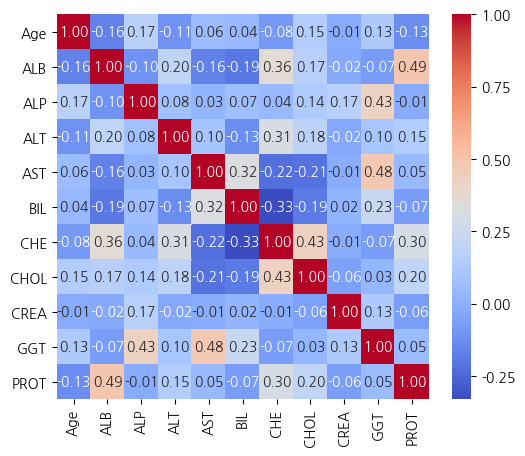

In [29]:
corr = df.drop('Category', axis =1).corr()

# 3. 히트맵 그리기
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()  # 변수간 상관관계를 보이지 않음

수치형 변수들에 대해서만 정규화를 진행하고 주성분분석을 진행한다

In [31]:
num = df.drop(columns =['Category','Sex']) # category, Sex 컬럼 제외

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

ss = StandardScaler()
num_scaled = ss.fit_transform(num)  

pca = PCA()
pca_fit = pca.fit(num_scaled)

pca_result = pd.DataFrame({'고유값': pca.singular_values_,\
              '분산 설명력': pca.explained_variance_ratio_,\
            '누적 분산 설명력':np.cumsum(pca.explained_variance_ratio_)})
print('주성분 분석 결과')
display(pca_result)

주성분 분석 결과


,고유값,분산 설명력,누적 분산 설명력
0,37.668811,0.221640,0.221640
1,32.385230,0.163824,0.385464
2,28.303095,0.125127,0.510592
3,25.030259,0.097862,0.608454
4,23.504640,0.086296,0.694750
5,20.896996,0.068211,0.762961
6,20.198784,0.063729,0.826689
7,18.966658,0.056191,0.882880
8,16.854372,0.044372,0.927252
9,16.579235,0.042935,0.970187


In [21]:
print('''
누적 분산설명력이 0.8을 넘기기 위해서는 7개의 주성분이 필요하다. 
주성분분석을 통한 차원축소의 효율이 높지 않다고 판단된다. 
그러므로 별도의 차원축소 없이 모델링을 진행한다.
''')


누적 분산설명력이 0.8을 넘기기 위해서는 7개의 주성분이 필요하다. 
주성분분석을 통한 차원축소의 효율이 높지 않다고 판단된다. 
그러므로 별도의 차원축소 없이 모델링을 진행한다.



## 2-1 데이터 불균형이 왜 문제인지 설명하고 불균형 해결방법에 대해 두가지를 설명하라

데이터 불균형은 종속변수의 특정 클래스 값이 다른 클래스 값에 비해 상대적으로 적은 경우를 의미한다.
대부분의 모델은 전체 정확도(accuracy)를 최대화하려고 하기 때문에 데이터가 많은 클래스에 편향되어 학습이 진행될 수 있다. 실제로 중요한 건 소수 클래스인데 이걸 못 잡으면 실무적으로 치명적 손실이 발생한다.  
1. 샘플링 기법  
오버샘플링과 언더샘플링으로 데이터 불균형을 해결할 수 있다. 
오버샘플링은 데이터가 적은 클래스의 데이터를 인위적으로 늘리는 방법이고, 언더샘플링은 데이터가 많은 클래스의 데이터를 줄이는 방법이다.    
오버샘플링은 과적합 위험, 언더샘플링은 정보 손실 가능성 존재 → 적절한 밸런싱 필요 
2. 클래스 가중치 조정  
분류 알고리즘에 class_weight=‘balanced’ 옵션 부여하여 손실 함수에 소수 클래스에 더 높은 페널티를 주어 학습 방향을 조정한다. 모델이 소수 클래스 오류에 더 민감하게 반응하도록 한다.

## 2-2 불균형 데이터 분류모델에 적합한 평가지표 3개 제시하고 그 이유 설명하라

소수 클래스가 존재하는 데이터셋에 대해서는 소수클래스를 잘 맞추었는지에 조금 더 관심을 두어야한다. 그것을 위해서 아래 3가지 지표를 활용할 수 있다.     
precision : 모델이 양성으로 예측한 데이터 중 실제로 양성인 데이터의 비율        
recall :  실제 양성 데이터 중에서 모델이 양성으로 올바르게 예측한 비율  
### 소수 클래스가 진짜 중요한 경우 → Recall이 더 중요
1. f1score 
- recall,precision의 조화평균, 두 지표간의 관계를 정량적 표현          
- 정밀도와 재현율을 동일하게 중요하게 여김  
2. f2score 
- Recall(재현율)을 Precision보다 더 중요하게 생각      

In [ ]:
from sklearn.metrics import fbeta_score

# β = 2 이면 F2-score
# f2 = fbeta_score(y_train, y_pred, beta=2, average='binary')

## 2-3 종속 변수를 정상(Category 0)과 비정상(Category 1,2,3)로 변경한 후 위의 2가지 불균형 처리 방법을 사용하고, 3가지 평가지표로 결과를 각각 평가하라.
(학습 규칙)
- 종속 변수를 이진화 후 불균형 처리 방법 진행
- 전처리 후 데이터 행의 index number를 초기화 하라(0부터 시작)
- index number 값이 5로 나눈 나머지가 0이라면 test, 그 외의 경우 train set으로 하여 진행
- 3가지 분류 모델을 사용하라

In [33]:
df2 = df.copy()

In [34]:
df2['Category']=df2['Category'].map({'0=B':0,'1=H':1,'2=F':1, '3=C':1})  # 정상과 비정상으로 변경

In [35]:
df2['Category'].value_counts()  # 클래스 별 분포, 불균형 데이터임을 확인

0    526
1     56
Name: Category, dtype: int64

In [36]:
df2['Sex'] = df2['Sex'].map({'m':1,'f':0}) # 범주형 변수 -> 수치화 (인코딩)

In [37]:
X = df2.drop("Category", axis = 1)  # 데이터 분할 
y = df2[['Category']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, \
                                                    stratify=y, random_state=42)

### 오버 샘플링 하지 않고, 분류 알고리즘에 가중치 조정

In [39]:
from sklearn.metrics import precision_score,recall_score,f1_score,fbeta_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("분류 알고리즘에 클래스 가중치 조절")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("F2-score:", fbeta_score(y_test, y_pred, beta=2))

분류 알고리즘에 클래스 가중치 조절
Precision: 1.0
Recall: 0.7142857142857143
F1-score: 0.8333333333333333
F2-score: 0.7575757575757576


### 오버 샘플링 SMOTE 진행

In [40]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state = 1, k_neighbors = 3)  # 이웃 수:  3
sm_X, sm_y = smote.fit_resample(X_train,y_train)
print(Counter(sm_y))

Counter({0: 394, 1: 394})


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score,recall_score,f1_score,fbeta_score

model1 = RandomForestClassifier(random_state=42)
model1.fit(sm_X, sm_y)
y_pred1 = model1.predict(X_test)

print("1. SMOTE 적용")
print("Precision:", precision_score(y_test, y_pred1))
print("Recall:", recall_score(y_test, y_pred1))
print("F1-score:", f1_score(y_test, y_pred1))
print("F2-score:", fbeta_score(y_test, y_pred1, beta=2))

1. SMOTE 적용
Precision: 1.0
Recall: 0.9285714285714286
F1-score: 0.962962962962963
F2-score: 0.9420289855072465


### 오버 샘플링 Kmeans SMOTE 진행

In [43]:
from imblearn.over_sampling import KMeansSMOTE

km = KMeansSMOTE(random_state = 1, k_neighbors = 3)

km_X, km_y = km.fit_resample(X_train, y_train)
print(Counter(km_y))  # 두개의 클래스 개수가 아예 같지 않아질 수 있음

Counter({1: 396, 0: 394})


In [44]:
model2 = RandomForestClassifier(random_state=42)
model2.fit(km_X, km_y)
y_pred2 = model2.predict(X_test)

print("2. KMeansSMOTE 적용")
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1-score:", f1_score(y_test, y_pred2))
print("F2-score:", fbeta_score(y_test, y_pred2, beta=2))

2. KMeansSMOTE 적용
Precision: 1.0
Recall: 0.7857142857142857
F1-score: 0.88
F2-score: 0.8208955223880596


## 3-1 1에서 전처리 완료한 데이터를 바탕으로 종속변수에서 0을 제외한 1,2,3의 데이터만 필터하여 분류모델 학습 및 평가를 진행하라. 
-> 셋 이상의 범주(class)**를 가지는 문제는 다중 분류(Multi-class Classification) 문제
(학습 규칙)
- 전처리 후 데이터 행의 index number를 초기화 하라(0부터 시작)
- index number 값이 5로 나눈 나머지가 0이라면 test, 그 외의 경우 train set으로 하여 진행
- 3개의 분류 모델을 사용하라

In [46]:
df3 = df.copy()
df3 = df3.loc[df3['Category'] != '0=B'].reset_index(drop= True)
df3['Category'] = df3['Category'].map({'1=H':1,'2=F':2, '3=C':3})
df3['Sex'] = df3['Sex'].map({'m':1,'f':0})
df3.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,23,1,47.0,19.1,38.9,164.2,17.0,7.09,3.20,79.3,90.4,70.1
1,1,25,1,42.0,38.2,63.3,187.7,14.0,6.00,4.28,66.9,40.2,70.5
2,1,27,1,45.0,27.5,10.5,37.8,10.0,8.77,3.20,55.2,35.9,74.5
3,1,32,1,45.0,34.6,44.3,96.2,16.0,10.11,6.28,81.2,48.1,82.1
4,1,32,1,41.0,34.4,12.1,60.9,6.0,13.80,5.48,45.4,33.1,71.1


In [47]:
df3['Category'].value_counts()   # 불균형 데이터 아님

3    24
1    20
2    12
Name: Category, dtype: int64

In [48]:
X = df3.drop("Category", axis = 1)
y = df3[['Category']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [49]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

In [50]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

# y_true: 실제 라벨, y_pred: 예측 라벨
# 4. 평가
print(f"Random Forest 정확도: {accuracy_score(y_test, y_pred_rfc):.4f}")
print(classification_report(y_test, y_pred_rfc))

Random Forest 정확도: 0.7857
              precision    recall  f1-score   support

           1       0.80      0.67      0.73         6
           2       0.33      0.50      0.40         2
           3       1.00      1.00      1.00         6

    accuracy                           0.79        14
   macro avg       0.71      0.72      0.71        14
weighted avg       0.82      0.79      0.80        14



- accuracy  
    • 전체 데이터 중에서 얼마나 맞췄는지
- macro avg  
	• 모든 클래스를 동일한 중요도로 간주하고 평균 낸 값
- weighted avg   
    • 클래스별 성능을 샘플 수 비중(weight)으로 평균  
    • 클래스 불균형 데이터셋에서는 주로 이걸 보고 판단함

## 다항 로지스틱 회귀 

In [147]:
#  일반 로지스틱 회귀는 이진 분류만 가능
#  다항 로지스틱 회귀는 클래스가 여러개 일때 확률을 구한다(Softmax 함수 이용)
#  -> 확률이 높은 클래스를 예측값으로 선택

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_z = scaler.fit_transform(X_train) 
X_test_z = scaler.transform(X_test)

In [52]:
X_train_z = pd.DataFrame(X_train_z, columns = X_train.columns)
X_test_z = pd.DataFrame(X_test_z, columns = X_test.columns)

In [53]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
lr.fit(X_train_z, y_train)

y_pred_lr = lr.predict(X_test_z)

# 4. 평가
print(f"로지스틱회귀 정확도: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

로지스틱회귀 정확도: 0.8571
              precision    recall  f1-score   support

           1       1.00      0.67      0.80         6
           2       0.50      1.00      0.67         2
           3       1.00      1.00      1.00         6

    accuracy                           0.86        14
   macro avg       0.83      0.89      0.82        14
weighted avg       0.93      0.86      0.87        14



In [54]:
from sklearn.svm import SVC

# SVM 모델 정의 및 학습
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_z, y_train)

# 3. 예측
y_pred_svm = svm.predict(X_test_z)

# 4. 평가
print(f"SVM 정확도: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\n분류 리포트:\n", classification_report(y_test, y_pred_svm))

SVM 정확도: 0.7143

분류 리포트:
               precision    recall  f1-score   support

           1       0.67      0.67      0.67         6
           2       0.33      0.50      0.40         2
           3       1.00      0.83      0.91         6

    accuracy                           0.71        14
   macro avg       0.67      0.67      0.66        14
weighted avg       0.76      0.71      0.73        14



## 3-2 학습한 모델 결과와 평가지표를 바탕으로 간염여부에 영향을 미치는 요소들에 대해 논의하라

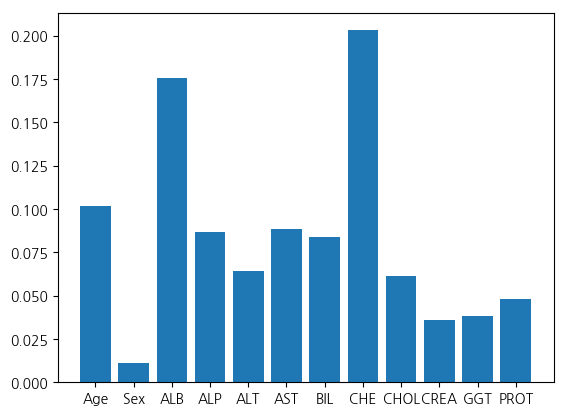

In [55]:
plt.bar(X.columns,rfc.feature_importances_)
plt.show()

# 적절히 모델 결과 해석과 트리류 모델 특징의 변수중요도 분석
# 랜덤포레스트 모델에서 CHE, ALB, Age 순으로 변수 중요도를 보인다.

### 다항 로지스틱 회귀에서 독립변수들의 영향 해석 -> 클래스 별로 회귀계수를 보고, 각 계수의 부호와 크기 그리고 오즈비로 해석 가능

In [56]:
import numpy as np
import pandas as pd

# 계수 확인
coef = lr.coef_  # shape: (n_classes, n_features)
odds_ratios = np.exp(coef)  # 오즈비로 해석

# 보기 좋게 출력
pd.DataFrame(odds_ratios, columns=X.columns, index=['Class 1', 'Class 2', 'Class 3']).T

,Class 1,Class 2,Class 3
Age,0.503631,1.364311,1.455373
Sex,1.142378,1.222197,0.716224
ALB,1.540043,1.690451,0.384118
ALP,1.034206,0.722087,1.339071
ALT,0.983459,1.053679,0.965018
AST,0.721251,1.273932,1.088347
BIL,1.305563,0.667833,1.146924
CHE,1.924451,1.796560,0.289235
CHOL,1.129706,0.971121,0.911510
CREA,0.978652,0.778206,1.313037


In [75]:
#  오즈비 해석:
#  값 > 1 → 해당 feature가 증가할수록 해당 클래스에 속할 오즈(odds)가 증가 (양의 영향)
#  값 < 1 → 해당 feature가 증가할수록 해당 클래스에 속할 오즈(odds)가 감소 (음의 영향)
#  값 ≈ 1 → 영향 거의 없음

# “변수 X가 1 단위 증가할 때, Class Y로 분류될 오즈는 Z배가 된다.”

#### 오즈비는 기준 클래스에 대한 상대적 비교이다. 기준 클래스 : Category = 1 인 Class 1

나이(Age): 1 단위 증가할수록 Class 2로 분류될 오즈는 약 1.703배 증가하므로,  
→ “고령일수록 간염 의심군(Class 2)에 속할 가능성이 높아진다”라고 해석할 수 있다.  
	•	ALT / ALP / AST: 간 수치 관련 변수로, 전반적으로 Class 3(간염 위험군)의 오즈가 높음   
→ “간 수치가 높을수록 간염 고위험군일 가능성이 높다”   
	•	ALB(알부민): Class 3에서 0.34 → “알부민 수치가 높아질수록 Class 3로 분류될 오즈 감소”  
→ 간 기능 저하를 나타낼 수 있음.   
	•	CHE: Class 2에서는 2.08 (높을수록 오즈 증가), Class 3에서는 0.31 (높을수록 오즈 감소)  
→ “CHE 수치는 중간 상태(Class 2)에서 높고, 위험군(Class 3)에서는 낮다”   

ALT의 오즈비는 1.35로, 1 단위 증가 시 간염 위험군(Class 2)에 분류될 오즈가 35% 증가하는 것으로 나타났다.   
반면, 알부민(ALB) 수치는 낮을수록 간염 위험군일 가능성이 높았으며, OR=0.34로 음의 영향을 보였다  

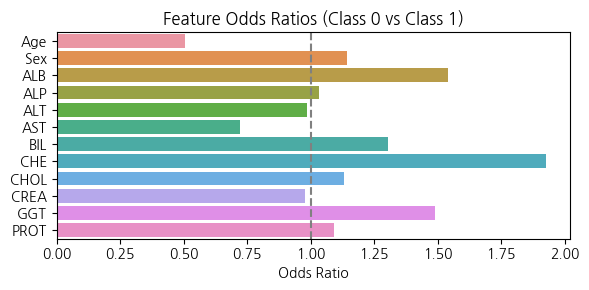

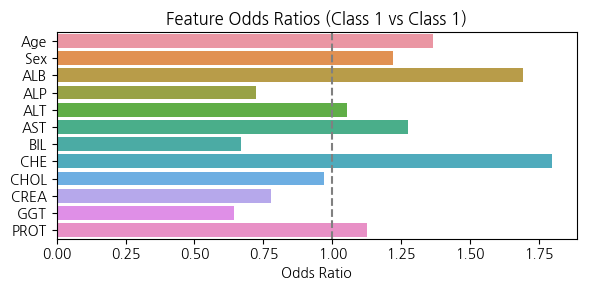

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns


for i, cls in enumerate(model.classes_):
    plt.figure(figsize=(6, 3))
    sns.barplot(x=odds_ratios[i], y=X.columns)
    plt.title(f'Feature Odds Ratios (Class {cls} vs Class 1)')
    plt.xlabel('Odds Ratio')
    plt.axvline(1.0, color='gray', linestyle='--')
    plt.tight_layout()
    plt.show()

## 4. 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15048032/fileData.do / 후처리, 통계청 날씨정보
- 데이터 링크 : 
    - ./data/p2_sb_2021.csv
    - ./data/p2_sb_2022.csv
    - ./data/p2_sb_2023.csv
    - ./data/p2_w_2021.csv
    - ./data/p2_w_2022.csv
    - ./data/p2_w_2023.csv
- 데이터 설명 : 
    - 21년~23년의 J시의 2개 지하철호선 지하철의 시간대별 승하차 인원 정보 데이터 (p2_sb_년도.csv)
        - X5~ X22 : 5시부터 22시 승차 또는 하차 인원, (X5 : 05시의 계절 날짜와 대응)
        - 역번호 : 각 정류장의 고유 번호
        - 승하차구분 : 승차 또는 하차
    - 21년~23년의 J시의 특정지역구의 시간대별 게절성 정보 데이터 (p2_w_년도.csv)
        - 시간별 J시의 날씨정보 

In [58]:
pd.set_option('display.max_columns', None)

In [1]:
import pandas as pd
p1 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_sb_2021.csv')
p2 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_sb_2022.csv')
p3 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_sb_2023.csv')

In [2]:
w1 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_w_2021.csv')
w2 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_w_2022.csv')
w3 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/p2_w_2023.csv')

In [140]:
display(p1.head())
display(p2.head())
display(p3.head())
display(w1.head())
display(w2.head())
display(w3.head())

,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2021-01-01,A,201,승차,22.0,25,61,64,58,53,94,107,109,149,196,168,178,177,117,138,90,58
1,2021-01-01,A,201,하차,12.0,49,87,142,101,110,84,110,105,125,114,86,119,63,26,25,62,18
2,2021-01-01,A,202,승차,43.0,53,70,119,94,103,176,295,331,323,437,447,881,531,335,441,403,137
3,2021-01-01,A,202,하차,21.0,154,238,727,425,356,377,351,330,342,321,333,331,163,119,110,137,47
4,2021-01-01,A,203,승차,21.0,27,48,81,62,60,116,204,156,197,197,203,213,190,145,208,135,76


,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2022-01-01,A,201,승차,16.0,36,55,100,92,96,209,297,268,287,389,443,424,385,240,358,359,115
1,2022-01-01,A,201,하차,9.0,88,196,209,150,136,154,278,253,311,249,223,196,161,84,103,130,65
2,2022-01-01,A,202,승차,41.0,39,79,124,168,200,415,660,607,752,796,977,1377,1200,922,985,1094,417
3,2022-01-01,A,202,하차,38.0,156,220,707,564,529,630,762,776,801,828,837,861,649,328,245,403,176
4,2022-01-01,A,203,승차,24.0,36,72,70,105,263,280,554,439,413,409,395,497,475,377,581,689,212


,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2023-01-01,A,201,승차,43.0,43,43,138,140,287,392,602,482,527,601,627,761,801,581,507,503,304
1,2023-01-01,A,201,하차,36.0,126,144,245,283,348,332,418,403,432,450,371,354,308,227,232,237,208
2,2023-01-01,A,202,승차,108.0,111,120,175,278,556,881,1097,1154,1258,1372,1556,1687,1901,1347,1333,1162,1029
3,2023-01-01,A,202,하차,114.0,312,387,869,899,773,1121,1106,1252,1236,1145,1319,1289,1082,874,732,612,414
4,2023-01-01,A,203,승차,52.0,69,107,238,244,553,673,801,880,806,774,847,748,714,554,508,423,366


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2021-01-01 00:00,-8.3,NaN,1.8,66,2.2,1016.4,0.0,0,-6.8
1,2021-01-01 01:00,-8.7,NaN,2.4,68,2.2,1016.4,0.0,0,-6.9
2,2021-01-01 02:00,-9.1,NaN,1.6,69,2.1,1016.2,0.0,0,-7.1
3,2021-01-01 03:00,-9.3,NaN,1.1,70,2.1,1016.8,0.0,0,-7.3
4,2021-01-01 04:00,-9.3,NaN,0.3,71,2.2,1016.2,0.0,0,-7.5


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2022-01-01 00:00,-8.5,NaN,1.9,41,1.3,1021.9,0,0,-7.0
1,2022-01-01 01:00,-9.2,NaN,1.8,42,1.3,1022.2,0,0,-7.2
2,2022-01-01 02:00,-9.5,NaN,1.2,43,1.3,1022.3,0,0,-7.5
3,2022-01-01 03:00,-9.3,NaN,1.4,46,1.4,1022.6,0,0,-7.6
4,2022-01-01 04:00,-9.6,NaN,1.7,48,1.4,1021.9,0,0,-7.6


,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도
0,2023-01-01 00:00,0.9,NaN,1.4,72,4.7,1018.5,9,9,-1.6
1,2023-01-01 01:00,1.5,NaN,1.9,71,4.9,1018.0,6,6,-1.4
2,2023-01-01 02:00,1.5,NaN,1.9,72,4.9,1017.8,9,8,-1.6
3,2023-01-01 03:00,1.6,NaN,1.6,74,5.1,1018.1,8,8,-1.8
4,2023-01-01 04:00,1.5,NaN,1.4,74,5.0,1018.1,9,9,-1.3


## 4-1 아래 조건들을 참고하여 전처리를 시행하고 훈련데이터에 대한 기초통계량을 구하시오
1. 승하차 데이터에서 X5~X22 모든컬럼이 0의 값을 가지는 경우 해당 날짜,호선,역번호 승하차 행은 제외한다. 
2. 승하차 데이터를 날짜,호선,역번호,시간대별(05~22시) 승객수의 총합을 구하여라(승차 + 하차), 결측치는 0명으로 간주한다. 컬럼명은 users로 변경한다.
3. 날짜 데이터의 강수 데이터는 결측치를 0, 그 외 컬럼의 결측치는 직전값으로 대치한다.
4. 날짜데이터와 일자,시간별 승하차인원 데이터를 동일날짜,시간에 대해 합친다.
5. 일자정보를 바탕으로 주말 여부를 나타내는 weekday컬럼을 추가한다. (주말=1,평일=0)
6. 21년,22년 데이터는 훈련데이터, 23년 데이터는 테스트 데이터로 사용한다.

In [10]:
p = pd.concat([p1,p2,p3], axis = 0).reset_index(drop = True)
w = pd.concat([w1,w2,w3], axis = 0).reset_index(drop = True)

In [14]:
p.head()

,날짜,호선,역번호,승하차구분,X5,X6,X7,X8,X9,X10,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22
0,2021-01-01,A,201,승차,22.0,25,61,64,58,53,...,109,149,196,168,178,177,117,138,90,58
1,2021-01-01,A,201,하차,12.0,49,87,142,101,110,...,105,125,114,86,119,63,26,25,62,18
2,2021-01-01,A,202,승차,43.0,53,70,119,94,103,...,331,323,437,447,881,531,335,441,403,137
3,2021-01-01,A,202,하차,21.0,154,238,727,425,356,...,330,342,321,333,331,163,119,110,137,47
4,2021-01-01,A,203,승차,21.0,27,48,81,62,60,...,156,197,197,203,213,190,145,208,135,76


In [62]:
# 방법 1.
cols = [f'X{i}' for i in range(5, 23)]  # x5 형태의 열만 가져오기 
p = p[~(p[cols].sum(axis=1) == 0)]  # 열을 기준으로 (가로로 더함)
p = p.fillna(0)
p_melt = p.groupby(['날짜','호선','역번호'])[cols].sum().reset_index().melt(['날짜','호선','역번호'])
p_melt = p_melt.rename(columns ={'variable':'시간','value':'users'})
p_melt['시간']= p_melt['시간'].str.replace("X","")
p_melt['일시'] =  p_melt['날짜'].astype(str) + ' ' + p_melt['시간'].astype(str) + ':00'
p_melt['일시'] = pd.to_datetime(p_melt['일시'],format='%Y-%m-%d %H')
p_melt.drop(['날짜','시간'], axis =1, inplace= True )

In [63]:
p_melt

,호선,역번호,users,일시
0,A,201,34.0,2021-01-01 05:00:00
1,A,202,64.0,2021-01-01 05:00:00
2,A,203,39.0,2021-01-01 05:00:00
3,A,204,23.0,2021-01-01 05:00:00
4,A,205,67.0,2021-01-01 05:00:00
...,...,...,...,...
1636231,B,338,373.0,2023-12-31 22:00:00
1636232,B,339,976.0,2023-12-31 22:00:00
1636233,B,340,287.0,2023-12-31 22:00:00
1636234,B,341,256.0,2023-12-31 22:00:00


In [142]:
# 방법 2.
p = p[p.iloc[:,4:].sum(axis = 1) != 0].reset_index(drop= True) # 열 기준으로 가로로 더함
p = p.fillna(0)
p = p.drop(columns = ['승하차구분']).groupby(['날짜','호선','역번호']).sum().reset_index()
p_melt = p.melt(['날짜','호선','역번호']).rename(columns ={'variable':'시간','value':'users'})
p_melt['시간']= p_melt['시간'].str.replace("X","")
p_melt['일시'] =  p_melt['날짜'].astype(str) + ' ' + p_melt['시간'].astype(str) + ':00' # Y-m-d H:M 까지는 형태 필요
p_melt['일시'] = pd.to_datetime(p_melt['일시'],format='%Y-%m-%d %H')
p_melt.drop(['날짜','시간'], axis =1, inplace= True )

In [107]:
# 방법 1과 2중 아무거나 실행해서 밑에 진행

In [64]:
w['강수량'] =w['강수량'].fillna(0)
w = w.sort_values("일시").fillna(method = 'ffill')
w['일시'] = pd.to_datetime(w['일시'],format='%Y-%m-%d %H')

In [65]:
df = pd.merge(p_melt, w)
df['주말여부']=0
df.loc[(df['일시'].dt.weekday == 5)|(df['일시'].dt.weekday == 6),'주말여부'] = 1

df['month'] = df['일시'].dt.month
df['day'] = df['일시'].dt.day
df['hour'] = df['일시'].dt.hour

df['호선'] = df['호선'].map({'A':1},{'B': 0}).fillna(0).astype(int)
df['호선'] = df['호선'].astype("category")
df['역번호'] = df['역번호'].astype("category")
df['주말여부'] = df['주말여부'].astype("category")

In [66]:
train = df[(df['일시'].dt.year == 2021)|(df['일시'].dt.year == 2022)].reset_index(drop= True)
test = df[(df['일시'].dt.year == 2023)].reset_index(drop= True)

In [67]:
train.describe().T # 이걸 보여주는 것이 문제 1이었음

,count,mean,std,min,25%,50%,75%,max
users,1090620.0,2093.877278,2346.067281,0.0,597.000,1347.0,2732.0,26183.0
기온,1090620.0,14.176355,11.175155,-18.5,6.000,15.4,23.6,36.3
강수량,1090620.0,0.171750,1.440923,0.0,0.000,0.0,0.0,64.7
풍속,1090620.0,2.481560,1.134005,0.0,1.700,2.3,3.1,8.6
습도,1090620.0,62.749391,18.919553,17.0,48.000,62.0,78.0,100.0
증기압,1090620.0,12.654094,8.796690,0.7,5.375,9.9,19.7,35.2
현지기압,1090620.0,1005.940944,8.094596,984.1,999.400,1006.3,1012.3,1025.8
전운량,1090620.0,4.974505,3.956197,0.0,0.000,6.0,9.0,10.0
중하층운량,1090620.0,3.064764,3.459133,0.0,0.000,1.0,7.0,10.0
지면온도,1090620.0,16.311941,13.159712,-12.7,5.100,17.1,25.7,59.8


In [68]:
train.describe(include = 'category')

,호선,역번호,주말여부
count,1090620,1090620,1090620
unique,2,83,2
top,1,342,0
freq,657000,13140,778374


## 4-2 전체 년도 데이터에 대해 users와 날씨 정보에 대해 상관관계를 분석하고 주말여부에 따른 users 변수의 차이가 존재하는지 통계적으로 확인하라.

In [69]:
df

,호선,역번호,users,일시,기온,강수량,풍속,습도,증기압,현지기압,전운량,중하층운량,지면온도,주말여부,month,day,hour
0,1,201,34.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
1,1,202,64.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
2,1,203,39.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
3,1,204,23.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
4,1,205,67.0,2021-01-01 05:00:00,-9.7,0.0,1.9,72,2.1,1015.6,0.0,0,-7.6,0,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1636231,0,338,373.0,2023-12-31 22:00:00,1.3,0.0,0.6,95,6.3,1014.1,0.0,0,-0.2,1,12,31,22
1636232,0,339,976.0,2023-12-31 22:00:00,1.3,0.0,0.6,95,6.3,1014.1,0.0,0,-0.2,1,12,31,22
1636233,0,340,287.0,2023-12-31 22:00:00,1.3,0.0,0.6,95,6.3,1014.1,0.0,0,-0.2,1,12,31,22
1636234,0,341,256.0,2023-12-31 22:00:00,1.3,0.0,0.6,95,6.3,1014.1,0.0,0,-0.2,1,12,31,22


In [149]:
display(df.drop(columns = ['호선','역번호','일시']).corr()['users'][1:].sort_values())
print("계절컬럼의 상관계수는 users와 큰 관계가 없다. 주말여부와 약한 음의 상관관계를 보인다.")

습도      -0.051947
중하층운량   -0.013331
현지기압    -0.011956
전운량     -0.008708
강수량     -0.003306
증기압      0.000272
day      0.011626
지면온도     0.023862
month    0.032211
기온       0.032292
풍속       0.051441
hour     0.096264
Name: users, dtype: float64

계절컬럼의 상관계수는 users와 큰 관계가 없다. 주말여부와 약한 음의 상관관계를 보인다.


In [71]:
from scipy.stats import shapiro, levene

group_A = df[df['주말여부'] == 0]
group_B  = df[df['주말여부'] == 1]


results = []

stat_A, p_A = shapiro(group_A['users'])
stat_B,  p_B  = shapiro(group_B['users'])
results.append({
    '변수': 'users',
    '정규성 group_A': round(p_A, 4),
    '정규성 group_B': round(p_B, 4),
    })

# 결과 출력
import pandas as pd
df_result = pd.DataFrame(results)
df_result

,변수,정규성 group_A,정규성 group_B
0,users,0.0,0.0


In [72]:
# 등분산성 검정 (Levene's test)
stat_levene, p_levene = levene(group_A['users'], group_B['users'])

# 결과 추가
df_result['등분산성 (Levene p-value)'] = round(p_levene, 4)

# 결과 출력
df_result

,변수,정규성 group_A,정규성 group_B,등분산성 (Levene p-value)
0,users,0.0,0.0,0.0


In [73]:
# 등분산성 검정 (Levene's test)
stat_levene, p_levene = levene(group_A['users'], group_B['users'])

# 결과 추가
df_result['등분산성 (Levene p-value)'] = round(p_levene, 4)

# 결과 출력
df_result

,변수,정규성 group_A,정규성 group_B,등분산성 (Levene p-value)
0,users,0.0,0.0,0.0


**3.	적절한 검정 선택**
   - 정규성 O + 등분산성 O → 독립표본 t-test
   - 정규성 O + 등분산성 X → Welch’s t-test
   - 정규성 X (둘 중 하나라도) → Mann-Whitney U test

In [74]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(group_A['users'], group_B['users'], alternative='two-sided')

print(f"Mann-Whitney U 검정 통계량: {stat:.4f}")
print(f"p-value: {p:.4f} → {'통계적으로 유의한 차이 있음' if p < 0.05 else '유의한 차이 없음'}")

Mann-Whitney U 검정 통계량: 347858575963.5000
p-value: 0.0000 → 통계적으로 유의한 차이 있음


## 4-3 users를 예측하는 2가지 회귀모델을 학습하고 모델에 대해 평가하라 (선형회귀 모델은 1개 필수 포함)

In [75]:
train = train.sample(10000)  # 데이터 개수 100만개 -> 너무 오래 걸려서 샘플링, 시험에서는 이런 이슈는 없을겁니다.
drop_col = ['일시','users']

train_x = train.drop(columns = drop_col)
train_y = train['users']

test_x = test.drop(columns = drop_col)
test_y = test['users']

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# 표준화 진행 
ss =StandardScaler()
train_x_ss = ss.fit_transform(train_x)
test_x_ss = ss.transform(test_x)

# 모델링 객체 생성 
rf =  RandomForestRegressor(random_state=1)
lr =  LinearRegression()  

# 훈련 및 예측
rf.fit(train_x_ss,train_y)  
lr.fit(train_x_ss,train_y)
pred_rf = rf.predict(test_x_ss)
pred_lr = lr.predict(test_x_ss)

# 평가 (R2, RMSE)
r2_rf = r2_score(test_y,pred_rf)
r2_lr = r2_score(test_y,pred_lr)

rf_mse = mean_squared_error(test_y, pred_rf)
lr_mse = mean_squared_error(test_y, pred_lr)

result = pd.DataFrame([[r2_rf,rf_mse],[r2_lr, lr_mse]],index=['랜덤포레스트','선형회귀'],columns=['R2','RMSE'])
result

# 역번호, 시간 등 적절한 전처리를 하지 않아도 강건한 랜덤포레스트에서 좀 더 좋은 결과가 나왔다.

,R2,RMSE
랜덤포레스트,0.808002,1.289491e+06
선형회귀,0.096914,6.065287e+06


# 통계 (40점)

## 데이터 설명
- 데이터 출처 : 자체 제작
- 데이터 링크 : ./data/s1.csv
- 데이터 설명 : A,B 두 공장의 특정 일자의 수율(%)데이터. 단, 불량률은 (100 - 수율)로 정의한다.
    

In [2]:
dt5 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/s1.csv')
print(dt5.info())
display(dt5.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    50 non-null     int64  
 1   month   50 non-null     object 
 2   day     50 non-null     int64  
 3   A       45 non-null     float64
 4   B       45 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB
None


,year,month,day,A,B
0,2023,Sep,7,56.9,42.3
1,2023,Feb,20,100.0,89.0
2,2023,Jun,15,19.3,59.0


In [4]:
dt5[(dt5['A'].isnull()) | (dt5['B'].isnull())]

,year,month,day,A,B
7,2023,Nov,26,NaN,68.8
9,2023,Mar,23,NaN,87.4
12,2023,Jun,24,35.6,NaN
16,2023,Dec,24,65.6,NaN
28,2023,Oct,12,32.3,NaN
29,2023,Nov,26,NaN,60.1
30,2023,Jul,22,NaN,69.1
35,2023,Sep,27,50.1,NaN
39,2023,Sep,16,NaN,60.7
48,2023,Sep,5,30.6,NaN


info에서 확인하였을 때 A, B 공장의 수율 결측치가 각각 5개씩 관찰된다.(총 10개 레코드)  
A, B 공장의 데이터는 각각 독립적이며, 임의일자에 측정한 데이터로 데이터들 간에도 독립적이기 때문에 대표값이나, 전/후위 결측치 보간이  
적절하지 않다. 따라서 10개 레코드를 삭제한다.

In [8]:
dt5 = dt5.dropna()
len(dt5)

40

## 5-1 공장별 불량률 차이 평균, 표준편차를 제시하시오.

In [12]:
#불량률: 100-수유
dt5['불량률A'] = 100 - dt5['A']
dt5['불량률B'] = 100 - dt5['B']

#A-B
dt5['불량률차이'] = dt5['불량률B'] - dt5['불량률A']

print(f"공장 불량률 차이 평균: {dt5['불량률차이'].mean()}")
print(f"공장 불량률 차이 표준편차: {dt5['불량률차이'].std()}")

공장 불량률 차이 평균: 5.274999999999999
공장 불량률 차이 표준편차: 22.341277768017036


B공장의 불량률이 A공장의 불량률보다 5.274999999999999% 높다.   
표준편차가 22.341277768017036로 높다. 이는 두 공장 간의 불량률의 차이가 일관적이지 않고 변동성이 크다는 것을 의미하며,   
B공장의 불량률이 더 높다고 단정하기보다는 데이터의 변동성을 고려한 추가적인 분석이 필요하다.

## 5-2. A,B 공장의 불량률 평균 차이가 존재하는지 확인하려 한다. 귀무,대립 가설을 설정하고 설명하라

두 공장의 불량률 평균 차이가 존재하는지 확인하기 위해서는 데이터가 정규성, 등분산성, 독립성(여기서는 독립표본)을 만족하는 경우   
모수검정인 독립표본 t-test, 이를 만족하지 않는다면 비모수검정인 Mann-Whitney U 검정을 실시한다.  

모수, 비모수 검정을 선택하기 위해 정규성 검정을 실시하고, 등분산 여부를 확인하기 위해 등분산성 검정을 실시한다.  

<정규성 검정가정:유의수준 0.05 하>
- H0: 0공장 불량률 데이터는 정규성을 만족한다.   
- H1: 0공장 불량률 데이터는 정규성을 만족하지 않는다.  

<등분산성 검정 가정: 유의수준 0.05 하>
- H0: 두 공장의 불량률 분포는 등분산이다. 
- H1: 두 공장의 불량률 분포는 등분산이 아니다.

In [24]:
from scipy.stats import anderson, jarque_bera, ks_2samp, probplot
ks_2samp(dt5['불량률A'], dt5['불량률B'])

KstestResult(statistic=0.325, pvalue=0.02860307028023343)

,name,stats_A,stats_B,pvalue_A,pvalue_B
0,Jarque-bera,0.883017,0.281989,2.332808e-01,6.454001e-01
1,K-S,0.883017,0.281989,3.236272e-24,1.818989e-52


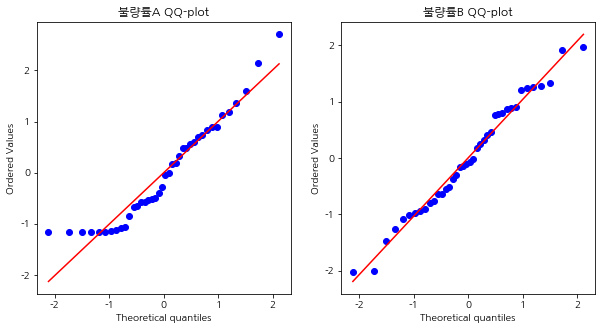

정규성 검정결과: A공장(0.000), B공장(0.000)로 유의확률 5% 하 귀무가설을 기각(정규성x)
등분산성 검정결과: p-value 0.019로 귀무가설을 기각(등분산성x)


In [35]:
from scipy.stats import shapiro, levene

#정규성 검정
s_stats1, p1 = shapiro(dt5['불량률A'])
s_stats2, p2 = shapiro(dt5['불량률B'])

#정규성: 기타
from scipy.stats import jarque_bera, kstest, probplot, zscore, norm

rs = pd.DataFrame(columns=['name', 'stats_A', 'stats_B', 'pvalue_A', 'pvalue_B'])
m_list = [jarque_bera, kstest]
m_title = ['Jarque-bera', 'K-S'] 

for name, m in zip(m_title, m_list):
    if name == 'K-S':
        stst1, p1 = m(dt5['불량률A'], cdf=norm.cdf)
        stst2, p2 = m(dt5['불량률B'], cdf=norm.cdf)
    else:
        stst1, p1 = m(dt5['불량률A'])
        stst2, p2 = m(dt5['불량률B'])
    rs.loc[len(rs)] = [name, stat1, stat2, p1, p2]
display(rs)    

z1 = zscore(dt5['불량률A'])
z2 = zscore(dt5['불량률B'])
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
probplot(z1, plot=ax[0])
probplot(z2, plot=ax[1])
ax[0].set_title('불량률A QQ-plot')
ax[1].set_title('불량률B QQ-plot')
plt.show()

#등분산성
l_stat, lp = levene(dt5['불량률A'], dt5['불량률B'])

print(f"정규성 검정결과: A공장({p1:.3f}), B공장({p2:.3f})로 유의확률 5% 하 귀무가설을", "기각(정규성x)" if(p1 < 0.05) | (p2 < 0.05) else "기각x(정규성)")
print(f"등분산성 검정결과: p-value {lp:.3f}로 귀무가설을", "기각(등분산성x)" if lp < 0.05 else "기각x(등분산성)")

정규성(A공장 불량률)을 만족하지 못하기 때문에 모수검정을 사용하지 못하여 비모수 검정인 Mann-Whitney U 검정을 실시한다.  

<유의확률 5% 하 가설수립>
- H0: 두 공장의 불량률 평균 차이가 없다. 
- H1: 두 공장의 불량률 평균 차이가 있다.

## 5-3. A,B의 차이가 있는지 통계검정 하고 설명하라

In [40]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(dt5['불량률A'], dt5['불량률B'], alternative = 'two-sided')

print(f"Mann-Whitney U 검정 U 통계량: {stat:.3f}")
print(f"유의확률 5% 하 p-value가 {p:.3f}로 귀무가설을", "기각(차이있음)" if p < 0.05 else "기각x(차이없음)")

Mann-Whitney U 검정 U 통계량: 630.500
유의확률 5% 하 p-value가 0.104로 귀무가설을 기각x(차이없음)


유의확률 5% 하 p-value 0.104로 크므로 귀무가설을 기각할 수 없다.  
따라서, A공장 불량률과 B공장 불량률 간 통계적으로 유의미한 차이가 없다. 

## 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15123586/fileData.do 후처리
- 데이터 링크 : ./data/s2.csv
- 데이터 설명 : 일자별 지하철 노선별 지연 데이터

In [170]:
dt6 =  pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/s2.csv')
print(dt6.info())
display(dt6.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지연ID    833 non-null    object
 1   지연일자    833 non-null    object
 2   노선      833 non-null    object
 3   최대지연시간  833 non-null    object
dtypes: object(4)
memory usage: 26.2+ KB
None


,지연ID,지연일자,노선,최대지연시간
0,ID_0,2023-09-01,1호선,15분
1,ID_1,2023-09-01,1호선,15분
2,ID_2,2023-09-01,4호선,10분


## 6-1. 노선에 상관없이 일별 최대 지연시간이 5~15분으로 발생하는 경우는 하나의 사건으로 보자.  해당 사건이 일자별 발생하는 빈도가 포아송분포를 따르는지 확인하는 방법 2가지를 기술하고 결과를 보여라

In [171]:
# 일단 데이터 가공
r_dt6 = dt6.copy()
r_dt6['최대지연시간'] = r_dt6['최대지연시간'].str.replace(r'분 이상|분', '', regex=True).astype(int)
r_dt6['해당'] = np.where(r_dt6['최대지연시간'].between(5, 15), 1, 0)
p_count = r_dt6.groupby('지연일자')['해당'].sum()
display(p_count.head())
print(f"원본 사이즈: {len(dt6['지연일자'].value_counts())}, 가공 사이즈 {len(p_count)}")

지연일자
2023-09-01    4
2023-09-04    2
2023-09-05    3
2023-09-06    4
2023-09-08    4
Name: 해당, dtype: int32

원본 사이즈: 256, 가공 사이즈 256


"분포"에 따른 적합성을 검정하는 것이기 때문에, 카이제곱 적합도 검정과 Kolmogorov-Smirnov(K-S) 검정을 사용한다. .

- 카이제곱 적합도 검정(Goodness of fit test): 관측값들이 어떤 이론이나 이론적 분포를 따르고 있는지 검정(기대도수 5이상)

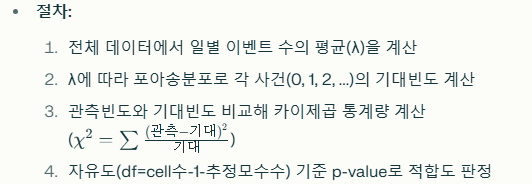

- Kolmogorov-Smirnov(K-S): 누적분포함수(CDF) 기반으로 관측값과 포아송분포의 전체 분포 형태가 얼마나 다른지를 측정

<절차> 
- 전체 데이터의 일별 이벤트 빈도를 정렬, 경험누적분포(Fn) 계산
- 같은 λ로 포아송분포 누적분포(F0) 계산
- 두 분포의 차이 중 최대값이 임계값(유의수준 α)보다 크면 “적합하지 않음”으로 판정

<유의확률 5% 하 가설수립>
- H0: 데이터는 포아송 분포를 따른다. 
- H1: 데이터는 포아송 분포를 따르지 않는다.

**왜 카이제곱과 K-S 검정을 써야하는가?**
1. 카이제곱 검정:  
  → 관측 빈도 데이터(“각 사건별 발생 횟수”)가 “이산적 이론분포(포아송)”에 유의하게 적합한지 양적으로 판단  
  → 각 사건 건수(0회, 1회, 2회, …)별 분할표로 직접 해석할 수 있어 “도수 기반 적합도 검증”에 최적화  
2. K-S 검정:  
  → 누적분포 전체(패턴)가 실제와 이론 값 간에 얼마나 괴리되는지 전체적으로 평가  
  → 표본이 적거나, “빈도분포”가 아닌 “순위(누적)”를 중시할 때 좋은 기준  
  → 특히, 데이터가 연속형이거나 구간별 구분이 애매할 때 강점  

In [175]:
from scipy.stats import poisson, chisquare, kstest

#1. 카이제곱 적합도검정
lamb = p_count.mean() #평균계산
obs_freq = p_count.value_counts().sort_index() #사건수별 빈도
expected_freq = [len(p_count) * poisson.pmf(k, lamb) for k in obs_freq.index] # 각 사건(수)별 기대빈도
expected_freq = np.array(expected_freq)*obs_freq.sum() / sum(expected_freq) # 기대 도수를 관측 총합에 맞춰 정규화
cstat, p1 = chisquare(obs_freq.values, expected_freq) #사건수별 빈도, 각 사건(수)별 기대빈도

print(f"카이제곱 적합도 검정 통계량: {cstat}")
print(f"카이제곱 적합도 검정 p-value: {p1} 으로 귀무가설", "기각(포아송x)" if p1<0.05 else "기각x(포아송)")

카이제곱 적합도 검정 통계량: 132.55667454905526
카이제곱 적합도 검정 p-value: 8.345434412211419e-25 으로 귀무가설 기각(포아송x)


위에서 카이제곱 적합도검정을 실시하였지만, 기대도수가 5이하인 값이 있어 포아송 분포 검정에 적합하지 않다.   
다음으로 k-s 검정을 실시한다. 

In [177]:
#ks 검정
kstats, p2 = kstest(p_count, cdf='poisson', args=(lamb, )) #args는 튜플이어야 함

print(f"K-S 검정 통계량: {kstats}")
print(f"K-S 검정 p-value: {p2} 으로 귀무가설", "기각(포아송x)" if p2<0.05 else "기각x(포아송)")

K-S 검정 통계량: 0.36068538573222353
K-S 검정 p-value: 2.4645849459712848e-30 으로 귀무가설 기각(포아송x)


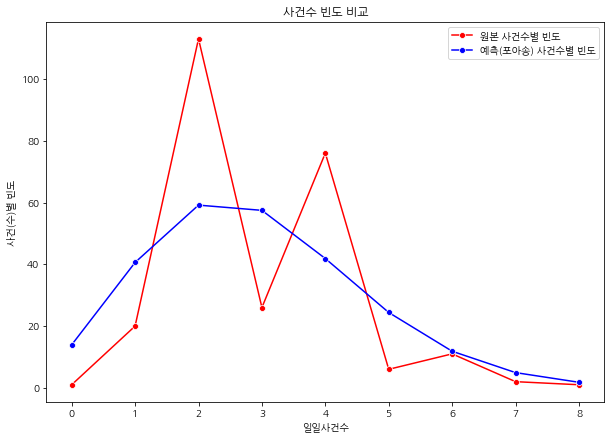

In [181]:
#시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.lineplot(x=obs_freq.index, y=obs_freq, ax = ax, marker='o', color='r', label='원본 사건수별 빈도')
sns.lineplot(x=obs_freq.index, y=expected_freq, ax=ax, marker='o', color='b', label='예측(포아송) 사건수별 빈도')
ax.set_title('사건수 빈도 비교')
ax.set_xlabel('일일사건수')
ax.set_ylabel('사건(수)별 빈도')
plt.show()

K-S 검정결과, 유의확률 5% 하에서 p-value 2.4645849459712848e-30로 귀무가설을 기각할 수 없다.  
따라서 일자별 사건빈도수는 포아송 분포를 따르지 않는다.

**기타**: 해석 어려움
- Anderson-Darling(A-D) 검정: 데이터 순위를 매기고, 포아송분포의 CDF와의 차이에 가중치를 두어 통계량을 산출
  - 특징: 분포의 꼬리, 즉 극단값 영역 적합성을 더 엄격하게 평가합니다(단, 공식적 p-value 해석은 어렵고 보조지표로 주로 활용

In [204]:
# Anderson-Darling
cdf_vals = poisson.cdf(np.sort(p_count), lamb) #누적분포

# log(0) 방지: CDF, 1-CDF 값이 0 또는 1이 되지 않도록 소수점 보정(clip)
eps = 1e-10
cdf_vals = np.clip(cdf_vals, eps, 1 - eps)
one_minus_cdf = 1 - cdf_vals[::-1]
one_minus_cdf = np.clip(one_minus_cdf, eps, 1 - eps)

# 4. A-D 통계량 계산
n = len(p_count) #사건수(=일자수)
i = np.arange(1, n+1) #사건 index
ad_stat = -n - np.mean((2*i - 1) * (np.log(cdf_vals) + np.log(one_minus_cdf)))
print(f"Anderson-Darling 통계량: {ad_stat:.4f}")

Anderson-Darling 통계량: 29.4932


## 6-2. 지연시간을 지연정도로 분류하라.  호선별 지연정도를 교차표로 구하여라.

- 10분 이하: 1
- 10분 초과-20분 이하: 2
- 20분 초과: 3

In [222]:
cond1 = dt6['최대지연시간'].str.replace(r"분 이상|분", "", regex=True).astype(int) > 20
cond2 = (dt6['최대지연시간'].str.replace(r"분 이상|분", "", regex=True).astype(int) > 10) & (dt6['최대지연시간'].str.replace(r"분 이상|분", "", regex=True).astype(int) <= 20) 
dt6['지연정도'] = np.where(cond1, '20분 초과', np.where(cond2, "10분 초과 - 20분 이하", "10분 이하"))
cr = pd.crosstab(dt6['노선'], dt6['지연정도'])
display(cr)

지연정도,10분 이하,10분 초과 - 20분 이하,20분 초과
노선,,,
1호선,269,67,16
4호선,324,144,13


## 6-3. 지하철 호선별로 지연정도가 차이가 있는지 확인하려한다. 귀무가설과 대립가설을 설정한 후 통계 검정을 실시하라

하나의 모집단의 호선 별(샘플별) 지연정도 차이 여부의 검정은 카이제곱 독립성 검정을 실시한다.   
유의확률 5% 하 검정을 실시한다.  

<가설수립>
- H0: 지하철 호선 별 지연정도의 차이가 없다.(지하철 노선과 지연정도는 독립)
- H1: 지하철 호선 별 지연정도의 차이가 있다.(지하철 노선과 지연정도는 독립이 아님)

In [224]:
from scipy.stats import chi2_contingency

stats, p, ddof, expected = chi2_contingency(cr)

print(f"카이제곱 검정통계량: {stats:.3f}, p-value: {p:.3f}")
print(f"유의확률 5% 하 귀무가설을", "기각(차이있음)" if p<0.05 else "기각x(차이없음)")

카이제곱 검정통계량: 13.866, p-value: 0.001
유의확률 5% 하 귀무가설을 기각(차이있음)


유의확률 5% 하 귀무가설을 기각하였으므로 지하철 호선별 지연정도의 차이가 있다. 

## 문제 7
## 데이터 설명
- 데이터 출처 : 자체제작
- 데이터 링크 : ./data/s3.csv
- 데이터 설명 : 시계열 정보를 가지는 250행의 데이터

In [226]:
dt7 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/33/data/s3.csv'\
                 , header=None)

print(dt7.info())
dt7.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       250 non-null    float64
dtypes: float64(1)
memory usage: 2.1 KB
None


,0
0,0.496714
1,0.308778
2,0.692133
3,2.070861
4,1.326845


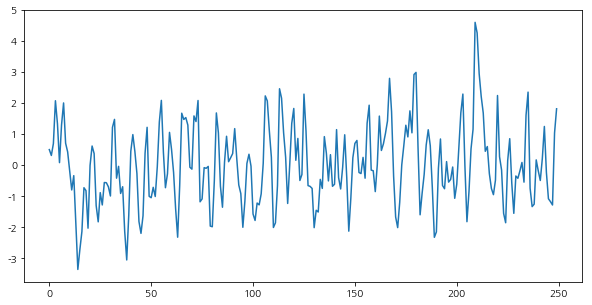

In [228]:
dt7.plot(figsize=(10, 5), legend=False)
plt.show()

## 7-1 ar ma arma에 대해 설명하고, ACF, PACF는 패턴을 통해 설명하라.

AR, MA, ARMA 모두 정상 시계열을 전제로 모델링하며, ACF/PACF 패턴을 보기 전에 시계열 정상화 필요

### 1. **AR (자기회귀, AutoRegressive)**

- **정의:**  
  과거 자신의 값들(시점별 lag 값)의 선형 조합으로 현재 값을 예측하는 모델  
  $$ X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \cdots + \phi_p X_{t-p} + \epsilon_t $$
  - $ p $: AR 차수(몇 시점 전까지 반영?)


### 2. **MA (이동평균, Moving Average)**

- **정의:**  
  과거 오차항의 선형 조합으로 현재 값을 예측하는 모델  
  $$ X_t = \epsilon_t + \theta_1 \epsilon_{t-1} + \cdots + \theta_q \epsilon_{t-q} $$
  - $ q $: MA 차수(몇 시점 전 오차 반영?)


### 3. **ARMA (자기회귀+이동평균, AutoRegressive Moving Average)**

- **정의:**  
  AR 모형과 MA 모형을 합친 형태로, 과거 자신의 값(AR)과 과거 오차(MA)를 모두 반영
  $$
  X_t = \phi_1 X_{t-1} + \cdots + \phi_p X_{t-p} + \epsilon_t + \theta_1 \epsilon_{t-1} + \cdots + \theta_q \epsilon_{t-q}
  $$


### 4. **ACF, PACF를 통한 모형판별 요약표**

| 모형    | ACF 패턴                          | PACF 패턴                      |
|---------|-----------------------------------|--------------------------------|
| AR(p)   | 점차적으로 감소(tailing off)      | **lag p에서 처음으로 끊김**        |
| MA(q)   | **lag q에서 처음으로 끊김**           | 점차적으로 감소(tailing off)   |
| ARMA    | 점차적으로 감소(tailing off)      | 점차적으로 감소(tailing off)   |

### **핵심 정리**
- **AR:** PACF에서 끊기고, ACF는 서서히 감소
- **MA:** ACF에서 끊기고, PACF는 서서히 감소
- **ARMA:** 둘 다 서서히 감소

> **즉, ACF/PACF 그래프에서 “어디서 끊기는가, 어디서 오래가나”로 AR, MA, ARMA를 진단할 수 있음** 

## 7-2 Acf pacf를 그리고 해석하라, 해당 Plot data를 기반으로 ARMA(p,q)모형 제시하라

acf, pacf를 그리기 전에 정상성을 만족시야 함
ADF 검정, KPSS 검정으로 정상성을 확인한다. 

**<ADF 검정 가설수립>** 
- H0: 단위근이 있다.(비정상시계열)
- H1: 단위근이 없다.(정상시계열)

**<KPSS 검정 가설수립>**  
- H0: 정상시계열이다.
- H1: 비정상시계열이다.

In [243]:
from statsmodels.tsa.stattools import adfuller, kpss

adf = adfuller(dt7)
kp = kpss(dt7)

rs_title = ['검정통계량', 'p-value']
ck = [('ADFuller', adf[:2]), ('KPSS', kp[:2])]

for name, value in ck:
    print(f"\n- {name}: ")
    for title, cc in zip(rs_title, value):
        print(f"{title}: {cc}")


- ADFuller: 
검정통계량: -5.615004257611437
p-value: 1.1798688224694751e-06

- KPSS: 
검정통계량: 0.3312745826153928
p-value: 0.1


정상성 검정결과, 유의확률 5% 하에서 p-value  
- ADFuller는 1.1798688224694751e-06로 귀무가설을 기각하여 정상 시계열
- KPSS는 0.1로 귀무가설을 기각할 수 없어서 정상 시계열  

즉, 정상시계열을 만족한다.  

차분, 변환없이 바로 ARMA(p, q)모델을 제시한다.  
p, q 파라미터 지정을 위해 ACF, PACF 그래프를 그린다.

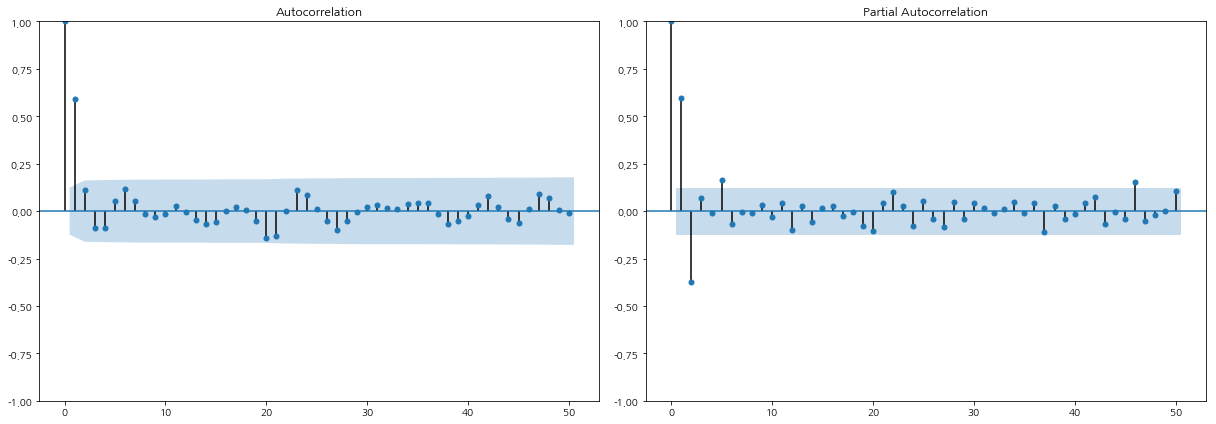

In [250]:
fig, ax = plt.subplots(1, 2, figsize=(17, 6))

from statsmodels.graphics.tsaplots import acf, pacf, plot_acf, plot_pacf

plot_acf(dt7, lags=50, ax=ax[0])
plot_pacf(dt7, lags = 50, ax=ax[1])
plt.tight_layout()
plt.show()

- ACF: lag 1에서 절단양상이 보이며, 이후 시점에서는 신뢰구간 내 값이 위치(q=1)
- PACF: lag 2에서 절단양상이 보이며, 이후 시점에서는 대체로 신뢰구간 내 값 위치(p=2)

**따라서, ARMA(2, 1) 모형을 구축**

In [263]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(dt7.values, order=(2, 0, 1)) #p, d, q, 일차원으로 넘겨야 plot이 나옴
rs = model.fit()

print(rs.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  250
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -345.443
Date:                Mon, 28 Jul 2025   AIC                            700.887
Time:                        15:48:32   BIC                            718.494
Sample:                             0   HQIC                           707.973
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0051      0.122     -0.042      0.966      -0.244       0.233
ar.L1          0.6199      0.172      3.613      0.000       0.284       0.956
ar.L2         -0.2538      0.120     -2.115      0.0

ARMA(2, 1) 모델 학습 결과이다. 

- Log Likelihood 값은 수치가 높을수록 모형 적합도가 높아짐 -345.443(낮음)
- AIC(낮을수록 좋음): 700.887
- BIC(낮을수록 좋음, 모델 단순성까지 고려): 718.494
- 모수추정결과: ma.L1를 제외한 모든 항목이 유의확률 5% 하에서 통계적으로 유의
    - ar.L1: 유의미한 AR(1) 계수
    - ar.L2: 유의미한 AR(2) 계수
    - ma.L1: MA(1) 계수 통계적으로 유의하지 않음
    - sigma2: 오차의 분산(낮을수록 예측이 정밀함)

- 잔차진단: 독립성, 등분산성 만족(정규성 불만족)
  - Ljung-Box: p-value 0.99 로 잔차에 자기상관 없음
  - Jarque-Bera (JB): p-value 0.01로 잔차가 정규분포를 따르지 않음
  - Heteroskedasticity (H): p-value 0.54로 잔차의 분산이 일정함

MAE: 1.028
RMSE: 1.295


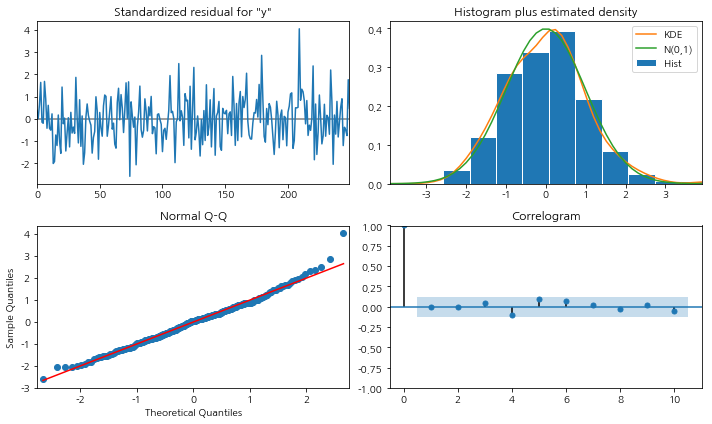

In [264]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

forecast = rs.get_forecast(steps=len(dt7))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(dt7, f_mean)
rmse = np.sqrt(mean_squared_error(dt7, f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
rs.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()

모델의 성능을 mse, rmse로 출력하고, 잔차 검정결과를 plot으로 표시하였다.  
수치 상으로는 정규성을 만족하지 않는다고 표시되었으나, Q-Q plot 상에서는 상 하단의 outterlier로 판단되는 일부 point를 제외하고는  
정규성을 만족하는 것으로 판단된다.  

따라서, 정규성, 등분산성, 독립성을 모두 만족하는 것으로 판단한다. 

# 최적화

In [270]:
from pmdarima import auto_arima

model2 = auto_arima(dt7.values, seasonal=False, stepwise=True)
print(model2.summary())

model2 = ARIMA(dt7.values, order=(3, 0, 1)).fit() #p, d, q, 일차원으로 넘겨야 plot이 나옴

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  250
Model:               SARIMAX(3, 0, 1)   Log Likelihood                -343.103
Date:                Mon, 28 Jul 2025   AIC                            696.207
Time:                        16:01:59   BIC                            713.814
Sample:                             0   HQIC                           703.293
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0126      0.129     -0.098      0.922      -0.265       0.240
ar.L2          0.2665      0.124      2.149      0.032       0.023       0.510
ar.L3         -0.2442      0.092     -2.646      0.0

auto arima로 p, q계수를 자동으로 최적화하였으며, ARMA(3, 1)모델로 생성하였다.  

AIC, BIC 값이 이전 모델에 비해 696.207, 713.814로 줄어들었으며(더 좋아졌으며),   
여전히 Jarque-Bera 잔차 정규성 검정결과, 정규성을 만족하지 않는 것으로 확인되었다.   
ar.L1 계수가 통계적으로 유의하지 않다.  

MAE: 1.028
RMSE: 1.296


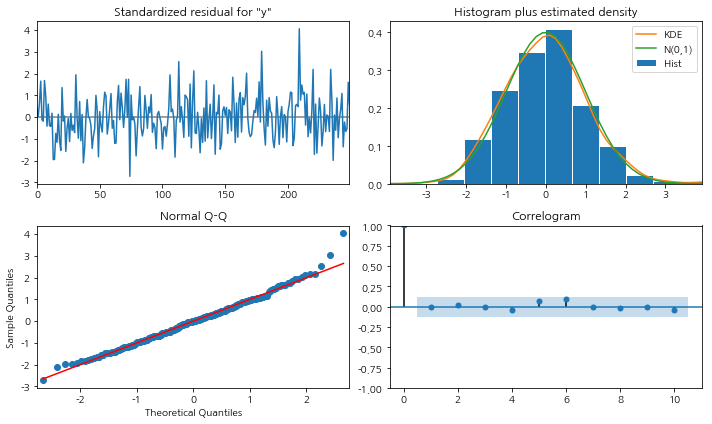

In [271]:
forecast = model2.get_forecast(steps=len(dt7))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(dt7, f_mean)
rmse = np.sqrt(mean_squared_error(dt7, f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
model2.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()